In [ ]:
            =================================
##🦠 Tuberculosis (TB) Epidemiological Analysis Dashboard ##
            =================================
## Project Overview

Tuberculosis (TB) remains one of the leading infectious disease threats worldwide. 
This project analyzes global tuberculosis burden data from the World Health Organization (WHO) to explore disease trends, geographical variations, mortality patterns, and key epidemiological indicators.

The analysis focuses on identifying changes in TB incidence, mortality, and case fatality rates across countries and WHO regions over time.
The final outputs include an exploratory data analysis (EDA) using Python and an interactive dashboard developed with Power BI to support data-driven public health insights.


In [ ]:
## Project Objective

The main objectives of this project are:

- Analyze global tuberculosis trends from WHO surveillance data.
- Examine TB incidence and mortality patterns across countries and regions.
- Calculate and evaluate key epidemiological indicators such as Case Fatality Rate (CFR).
- Identify countries with the highest TB burden.
- Visualize temporal and geographical patterns using Python and Power BI.
- Generate insights that can support public health decision-making.

In [ ]:
## Dataset Description

Source:
World Health Organization (WHO) Global Tuberculosis Programme.

Dataset:
WHO TB Burden Estimates.

The dataset includes annual tuberculosis estimates by country, covering:

- Population estimates.
- Estimated TB incidence.
- Estimated TB mortality.
- Incidence and mortality rates per 100,000 population.
- Case Fatality Rate (CFR).
- WHO geographical regions.

Time period:
2000 onwards.

Unit of analysis:
Country-year level.

In [2]:
# Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
%matplotlib inline

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
## 5. Load Dataset

The dataset used in this project is the WHO Global Tuberculosis Burden Estimates dataset.
It contains annual estimates of tuberculosis incidence, mortality, and epidemiological indicators by country.

In [3]:
df = pd.read_csv(r"C:/data/tb_burden_estimates.csv.csv")

In [4]:
df.head()

,country,iso2,ISO3,iso_numeric,WHO_Region,Year,Population,TB_Incidence_Rate,TB_Cases,e_tbhiv_prct,...,e_mort_100k_hi,TB_Deaths,cfr,Case_Fatality_Rate,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,20130323,148.0,30000.0,0.02,...,70.0,10000.0,0.34,34.0,19.0,50.0,35.0,24.0,2.3,77.0
1,Afghanistan,AF,AFG,4,EMR,2001,20284311,175.0,35000.0,0.01,...,76.0,11000.0,0.32,32.0,20.0,46.0,50.0,29.0,3.8,76.0
2,Afghanistan,AF,AFG,4,EMR,2002,21378110,197.0,42000.0,0.01,...,80.0,13000.0,0.30,30.0,19.0,42.0,65.0,33.0,5.6,78.0
3,Afghanistan,AF,AFG,4,EMR,2003,22733047,215.0,49000.0,0.01,...,92.0,15000.0,0.32,32.0,21.0,44.0,61.0,28.0,6.1,63.0
4,Afghanistan,AF,AFG,4,EMR,2004,23560660,228.0,54000.0,0.01,...,89.0,16000.0,0.29,29.0,20.0,40.0,78.0,34.0,9.1,72.0


In [5]:
# Dataset dimensions
df.shape

(5347, 42)

In [6]:
# First five rows
df.head()

,country,iso2,ISO3,iso_numeric,WHO_Region,Year,Population,TB_Incidence_Rate,TB_Cases,e_tbhiv_prct,...,e_mort_100k_hi,TB_Deaths,cfr,Case_Fatality_Rate,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,20130323,148.0,30000.0,0.02,...,70.0,10000.0,0.34,34.0,19.0,50.0,35.0,24.0,2.3,77.0
1,Afghanistan,AF,AFG,4,EMR,2001,20284311,175.0,35000.0,0.01,...,76.0,11000.0,0.32,32.0,20.0,46.0,50.0,29.0,3.8,76.0
2,Afghanistan,AF,AFG,4,EMR,2002,21378110,197.0,42000.0,0.01,...,80.0,13000.0,0.30,30.0,19.0,42.0,65.0,33.0,5.6,78.0
3,Afghanistan,AF,AFG,4,EMR,2003,22733047,215.0,49000.0,0.01,...,92.0,15000.0,0.32,32.0,21.0,44.0,61.0,28.0,6.1,63.0
4,Afghanistan,AF,AFG,4,EMR,2004,23560660,228.0,54000.0,0.01,...,89.0,16000.0,0.29,29.0,20.0,40.0,78.0,34.0,9.1,72.0


In [7]:
# Column names
df.columns

Index(['country', 'iso2', 'ISO3', 'iso_numeric', 'WHO_Region', 'Year',
       'Population', 'TB_Incidence_Rate', 'TB_Cases', 'e_tbhiv_prct',
       'e_tbhiv_prct_lo', 'e_tbhiv_prct_hi', 'e_inc_tbhiv_100k',
       'e_inc_tbhiv_100k_lo', 'e_inc_tbhiv_100k_hi', 'e_inc_tbhiv_num',
       'e_inc_tbhiv_num_lo', 'e_inc_tbhiv_num_hi', 'e_mort_exc_tbhiv_100k',
       'e_mort_exc_tbhiv_100k_lo', 'e_mort_exc_tbhiv_100k_hi',
       'e_mort_exc_tbhiv_num', 'e_mort_exc_tbhiv_num_lo',
       'e_mort_exc_tbhiv_num_hi', 'e_mort_tbhiv_100k', 'e_mort_tbhiv_100k_lo',
       'e_mort_tbhiv_100k_hi', 'e_mort_tbhiv_num', 'e_mort_tbhiv_num_lo',
       'e_mort_tbhiv_num_hi', 'TB_Mortality_Rate', 'e_mort_100k_lo',
       'e_mort_100k_hi', 'TB_Deaths', 'cfr', 'Case_Fatality_Rate',
       'cfr_pct_lo', 'cfr_pct_hi', 'c_newinc_100k', 'c_cdr', 'c_cdr_lo',
       'c_cdr_hi'],
      dtype='object')

In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5347 entries, 0 to 5346
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   5347 non-null   object 
 1   iso2                      5322 non-null   object 
 2   ISO3                      5347 non-null   object 
 3   iso_numeric               5347 non-null   int64  
 4   WHO_Region                5347 non-null   object 
 5   Year                      5347 non-null   int64  
 6   Population                5347 non-null   int64  
 7   TB_Incidence_Rate         5322 non-null   float64
 8   TB_Cases                  5322 non-null   float64
 9   e_tbhiv_prct              4452 non-null   float64
 10  e_tbhiv_prct_lo           0 non-null      float64
 11  e_tbhiv_prct_hi           0 non-null      float64
 12  e_inc_tbhiv_100k          4452 non-null   float64
 13  e_inc_tbhiv_100k_lo       4452 non-null   float64
 14  e_inc_tb

In [9]:
# Summary statistics
df.describe(include="all")

,country,iso2,ISO3,iso_numeric,WHO_Region,Year,Population,TB_Incidence_Rate,TB_Cases,e_tbhiv_prct,...,e_mort_100k_hi,TB_Deaths,cfr,Case_Fatality_Rate,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
count,5347,5322,5347,5347.000000,5347,5347.00000,5.347000e+03,5322.000000,5.322000e+03,4452.000000,...,5322.000000,5.322000e+03,4532.000000,4532.000000,4532.000000,4532.000000,5140.000000,4983.000000,4983.000000,4983.000000
unique,217,216,217,NaN,6,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,AF,AFG,NaN,EUR,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,25,25,25,NaN,1345,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,432.459323,NaN,2012.04208,3.349880e+07,138.209557,5.287482e+04,11.858643,...,46.897856,9.368417e+03,0.163195,16.319506,9.291924,24.214254,73.059726,66.158017,50.941056,92.285892
std,NaN,NaN,NaN,253.156668,NaN,7.20370,1.320868e+08,214.277454,2.497612e+05,16.504344,...,116.682235,4.611179e+04,0.121882,12.188248,5.672298,20.769945,103.481641,20.591071,20.953894,51.924977
min,NaN,NaN,NaN,4.000000,NaN,2000.00000,1.552000e+03,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,2.600000,0.460000,4.100000
25%,NaN,NaN,NaN,212.000000,NaN,2006.00000,7.593660e+05,11.000000,2.700000e+02,1.100000,...,1.000000,2.200000e+01,0.070000,7.000000,5.000000,9.000000,9.900000,51.000000,34.000000,74.000000
50%,NaN,NaN,NaN,430.000000,NaN,2012.00000,5.963198e+06,53.500000,3.500000e+03,5.000000,...,5.700000,3.000000e+02,0.120000,12.000000,8.000000,16.000000,36.000000,66.000000,53.000000,90.000000
75%,NaN,NaN,NaN,646.000000,NaN,2018.00000,2.163270e+07,181.000000,1.900000e+04,15.000000,...,40.000000,3.200000e+03,0.240000,24.000000,13.000000,36.000000,94.250000,81.000000,66.000000,100.000000


In [ ]:
## 6. Initial Data Exploration (EDA)

This section provides an initial exploration of the tuberculosis dataset to understand its structure, dimensions, data types, missing values, and overall characteristics before data cleaning and analysis.

In [4]:
# Display the number of rows and columns

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 5347
Number of Columns: 42


In [5]:
# Display the first five rows

df.head()

,country,iso2,ISO3,iso_numeric,WHO_Region,Year,Population,TB_Incidence_Rate,TB_Cases,e_tbhiv_prct,...,e_mort_100k_hi,TB_Deaths,cfr,Case_Fatality_Rate,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,20130323,148.0,30000.0,0.02,...,70.0,10000.0,0.34,34.0,19.0,50.0,35.0,24.0,2.3,77.0
1,Afghanistan,AF,AFG,4,EMR,2001,20284311,175.0,35000.0,0.01,...,76.0,11000.0,0.32,32.0,20.0,46.0,50.0,29.0,3.8,76.0
2,Afghanistan,AF,AFG,4,EMR,2002,21378110,197.0,42000.0,0.01,...,80.0,13000.0,0.30,30.0,19.0,42.0,65.0,33.0,5.6,78.0
3,Afghanistan,AF,AFG,4,EMR,2003,22733047,215.0,49000.0,0.01,...,92.0,15000.0,0.32,32.0,21.0,44.0,61.0,28.0,6.1,63.0
4,Afghanistan,AF,AFG,4,EMR,2004,23560660,228.0,54000.0,0.01,...,89.0,16000.0,0.29,29.0,20.0,40.0,78.0,34.0,9.1,72.0


In [6]:
df.tail()

,country,iso2,ISO3,iso_numeric,WHO_Region,Year,Population,TB_Incidence_Rate,TB_Cases,e_tbhiv_prct,...,e_mort_100k_hi,TB_Deaths,cfr,Case_Fatality_Rate,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
5342,Zimbabwe,ZW,ZWE,716,AFR,2020,15526885,189.0,29000.0,61.0,...,65.0,7600.0,0.27,27.0,16.0,38.0,101.0,54.0,41.0,74.0
5343,Zimbabwe,ZW,ZWE,716,AFR,2021,15797209,198.0,31000.0,62.0,...,72.0,8600.0,0.28,28.0,17.0,41.0,103.0,52.0,40.0,74.0
5344,Zimbabwe,ZW,ZWE,716,AFR,2022,16069054,209.0,34000.0,62.0,...,73.0,9200.0,0.28,28.0,17.0,41.0,113.0,54.0,41.0,79.0
5345,Zimbabwe,ZW,ZWE,716,AFR,2023,16340822,209.0,34000.0,62.0,...,70.0,8900.0,0.27,27.0,16.0,39.0,118.0,56.0,42.0,85.0
5346,Zimbabwe,ZW,ZWE,716,AFR,2024,16634364,203.0,34000.0,62.0,...,65.0,8200.0,0.25,25.0,14.0,38.0,122.0,60.0,45.0,95.0


In [7]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5347 entries, 0 to 5346
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   5347 non-null   object 
 1   iso2                      5322 non-null   object 
 2   ISO3                      5347 non-null   object 
 3   iso_numeric               5347 non-null   int64  
 4   WHO_Region                5347 non-null   object 
 5   Year                      5347 non-null   int64  
 6   Population                5347 non-null   int64  
 7   TB_Incidence_Rate         5322 non-null   float64
 8   TB_Cases                  5322 non-null   float64
 9   e_tbhiv_prct              4452 non-null   float64
 10  e_tbhiv_prct_lo           0 non-null      float64
 11  e_tbhiv_prct_hi           0 non-null      float64
 12  e_inc_tbhiv_100k          4452 non-null   float64
 13  e_inc_tbhiv_100k_lo       4452 non-null   float64
 14  e_inc_tb

In [8]:
# Summary statistics for numerical variables

df.describe()

,iso_numeric,Year,Population,TB_Incidence_Rate,TB_Cases,e_tbhiv_prct,e_tbhiv_prct_lo,e_tbhiv_prct_hi,e_inc_tbhiv_100k,e_inc_tbhiv_100k_lo,...,e_mort_100k_hi,TB_Deaths,cfr,Case_Fatality_Rate,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
count,5347.000000,5347.00000,5.347000e+03,5322.000000,5.322000e+03,4452.000000,0.0,0.0,4452.000000,4452.000000,...,5322.000000,5.322000e+03,4532.000000,4532.000000,4532.000000,4532.000000,5140.000000,4983.000000,4983.000000,4983.000000
mean,432.459323,2012.04208,3.349880e+07,138.209557,5.287482e+04,11.858643,NaN,NaN,38.033897,17.303989,...,46.897856,9.368417e+03,0.163195,16.319506,9.291924,24.214254,73.059726,66.158017,50.941056,92.285892
std,253.156668,7.20370,1.320868e+08,214.277454,2.497612e+05,16.504344,NaN,NaN,119.057162,51.698139,...,116.682235,4.611179e+04,0.121882,12.188248,5.672298,20.769945,103.481641,20.591071,20.953894,51.924977
min,4.000000,2000.00000,1.552000e+03,0.000000,0.000000e+00,0.000000,NaN,NaN,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,2.600000,0.460000,4.100000
25%,212.000000,2006.00000,7.593660e+05,11.000000,2.700000e+02,1.100000,NaN,NaN,0.270000,0.100000,...,1.000000,2.200000e+01,0.070000,7.000000,5.000000,9.000000,9.900000,51.000000,34.000000,74.000000
50%,430.000000,2012.00000,5.963198e+06,53.500000,3.500000e+03,5.000000,NaN,NaN,2.600000,1.300000,...,5.700000,3.000000e+02,0.120000,12.000000,8.000000,16.000000,36.000000,66.000000,53.000000,90.000000
75%,646.000000,2018.00000,2.163270e+07,181.000000,1.900000e+04,15.000000,NaN,NaN,15.000000,7.800000,...,40.000000,3.200000e+03,0.240000,24.000000,13.000000,36.000000,94.250000,81.000000,66.000000,100.000000
max,894.000000,2024.00000,1.450936e+09,2700.000000,3.590000e+06,84.000000,NaN,NaN,1320.000000,693.000000,...,1890.000000,1.040000e+06,1.000000,100.000000,44.000000,100.000000,947.000000,190.000000,160.000000,1600.000000


In [9]:
# Check missing values

missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

e_tbhiv_prct_lo             5347
e_tbhiv_prct_hi             5347
e_inc_tbhiv_100k_hi          895
e_tbhiv_prct                 895
e_inc_tbhiv_100k             895
e_inc_tbhiv_100k_lo          895
e_inc_tbhiv_num              895
e_inc_tbhiv_num_lo           895
e_inc_tbhiv_num_hi           895
e_mort_tbhiv_num_hi          815
e_mort_tbhiv_num             815
e_mort_tbhiv_num_lo          815
e_mort_tbhiv_100k            815
cfr_pct_hi                   815
e_mort_tbhiv_100k_lo         815
cfr_pct_lo                   815
e_mort_tbhiv_100k_hi         815
e_mort_exc_tbhiv_100k_lo     815
e_mort_exc_tbhiv_num_hi      815
e_mort_exc_tbhiv_num_lo      815
e_mort_exc_tbhiv_num         815
e_mort_exc_tbhiv_100k_hi     815
cfr                          815
e_mort_exc_tbhiv_100k        815
Case_Fatality_Rate           815
c_cdr                        364
c_cdr_lo                     364
c_cdr_hi                     364
c_newinc_100k                207
TB_Deaths                     25
e_mort_100

In [10]:
# Check duplicated rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
# Number of unique countries

print("Countries:", df["country"].nunique())

Countries: 217


In [13]:
# WHO Regions

df["WHO_Region"].value_counts()

WHO_Region
EUR    1345
AFR    1164
AMR    1115
WPR     925
EMR     550
SEA     248
Name: count, dtype: int64

In [14]:
print("Start Year:", df["Year"].min())
print("End Year:", df["Year"].max())

Start Year: 2000
End Year: 2024


In [15]:
df.groupby("WHO_Region")["country"].nunique().sort_values(ascending=False)

WHO_Region
EUR    55
AFR    47
AMR    46
WPR    37
EMR    22
SEA    10
Name: country, dtype: int64

In [ ]:
## 7. Data Cleaning

Data cleaning is a critical step in epidemiological data analysis. This section focuses on improving data quality by checking for missing values, removing duplicate records, selecting relevant variables, renaming columns, verifying data types, and preparing the dataset for further analysis.

In [16]:
# Create a copy of the original dataset

tb = df.copy()

In [17]:
print("Rows and Columns:", tb.shape)

Rows and Columns: (5347, 42)


In [18]:
tb.isnull().sum().sort_values(ascending=False)

e_tbhiv_prct_hi             5347
e_tbhiv_prct_lo             5347
e_inc_tbhiv_100k_lo          895
e_inc_tbhiv_num_hi           895
e_inc_tbhiv_num              895
e_inc_tbhiv_100k_hi          895
e_inc_tbhiv_100k             895
e_tbhiv_prct                 895
e_inc_tbhiv_num_lo           895
e_mort_exc_tbhiv_100k_hi     815
e_mort_tbhiv_num_lo          815
e_mort_exc_tbhiv_num_lo      815
e_mort_exc_tbhiv_num_hi      815
e_mort_exc_tbhiv_100k        815
e_mort_tbhiv_100k            815
e_mort_tbhiv_100k_lo         815
e_mort_exc_tbhiv_100k_lo     815
e_mort_exc_tbhiv_num         815
e_mort_tbhiv_num             815
e_mort_tbhiv_num_hi          815
cfr                          815
Case_Fatality_Rate           815
cfr_pct_lo                   815
cfr_pct_hi                   815
e_mort_tbhiv_100k_hi         815
c_cdr                        364
c_cdr_lo                     364
c_cdr_hi                     364
c_newinc_100k                207
iso2                          25
TB_Cases  

In [19]:
print("Duplicate Records:", tb.duplicated().sum())

Duplicate Records: 0


In [22]:
# Keep only the columns required for analysis and dashboard

tb = tb[
    [
        "country",
        "ISO3",
        "WHO_Region",
        "Year",
        "Population",
        "TB_Cases",
        "TB_Incidence_Rate",
        "TB_Deaths",
        "TB_Mortality_Rate",
        "Case_Fatality_Rate",
    ]
]

tb.head()

,country,ISO3,WHO_Region,Year,Population,TB_Cases,TB_Incidence_Rate,TB_Deaths,TB_Mortality_Rate,Case_Fatality_Rate
0,Afghanistan,AFG,EMR,2000,20130323,30000.0,148.0,10000.0,50.0,34.0
1,Afghanistan,AFG,EMR,2001,20284311,35000.0,175.0,11000.0,55.0,32.0
2,Afghanistan,AFG,EMR,2002,21378110,42000.0,197.0,13000.0,59.0,30.0
3,Afghanistan,AFG,EMR,2003,22733047,49000.0,215.0,15000.0,68.0,32.0
4,Afghanistan,AFG,EMR,2004,23560660,54000.0,228.0,16000.0,67.0,29.0


In [23]:
tb.rename(columns={"country": "Country"}, inplace=True)

In [24]:
tb.head()

,Country,ISO3,WHO_Region,Year,Population,TB_Cases,TB_Incidence_Rate,TB_Deaths,TB_Mortality_Rate,Case_Fatality_Rate
0,Afghanistan,AFG,EMR,2000,20130323,30000.0,148.0,10000.0,50.0,34.0
1,Afghanistan,AFG,EMR,2001,20284311,35000.0,175.0,11000.0,55.0,32.0
2,Afghanistan,AFG,EMR,2002,21378110,42000.0,197.0,13000.0,59.0,30.0
3,Afghanistan,AFG,EMR,2003,22733047,49000.0,215.0,15000.0,68.0,32.0
4,Afghanistan,AFG,EMR,2004,23560660,54000.0,228.0,16000.0,67.0,29.0


In [ ]:
## 8. Feature Engineering

Feature engineering involves creating new variables from existing data to improve analysis and visualization. These derived features help identify temporal patterns, categorize disease burden, and enhance dashboard interactivity.

In [25]:
# Population in millions

tb["Population_Millions"] = tb["Population"] / 1_000_000

In [26]:
# Create decade groups

tb["Decade"] = (tb["Year"] // 10) * 10

tb["Decade"] = tb["Decade"].astype(str) + "s"

In [27]:
# Categorize TB incidence rate

tb["TB_Burden"] = pd.cut(
    tb["TB_Incidence_Rate"],
    bins=[0, 100, 200, float("inf")],
    labels=["Low", "Medium", "High"]
)

In [28]:
# Categorize mortality rate

tb["Mortality_Level"] = pd.cut(
    tb["TB_Mortality_Rate"],
    bins=[0, 20, 50, float("inf")],
    labels=["Low", "Moderate", "High"]
)

In [29]:
# Categorize case fatality rate

tb["CFR_Level"] = pd.cut(
    tb["Case_Fatality_Rate"],
    bins=[0, 5, 10, float("inf")],
    labels=["Low", "Moderate", "High"]
)

In [30]:
tb.head()

,Country,ISO3,WHO_Region,Year,Population,TB_Cases,TB_Incidence_Rate,TB_Deaths,TB_Mortality_Rate,Case_Fatality_Rate,Population_Millions,Decade,TB_Burden,Mortality_Level,CFR_Level
0,Afghanistan,AFG,EMR,2000,20130323,30000.0,148.0,10000.0,50.0,34.0,20.130323,2000s,Medium,Moderate,High
1,Afghanistan,AFG,EMR,2001,20284311,35000.0,175.0,11000.0,55.0,32.0,20.284311,2000s,Medium,High,High
2,Afghanistan,AFG,EMR,2002,21378110,42000.0,197.0,13000.0,59.0,30.0,21.378110,2000s,Medium,High,High
3,Afghanistan,AFG,EMR,2003,22733047,49000.0,215.0,15000.0,68.0,32.0,22.733047,2000s,High,High,High
4,Afghanistan,AFG,EMR,2004,23560660,54000.0,228.0,16000.0,67.0,29.0,23.560660,2000s,High,High,High


In [31]:
tb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5347 entries, 0 to 5346
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Country              5347 non-null   object  
 1   ISO3                 5347 non-null   object  
 2   WHO_Region           5347 non-null   object  
 3   Year                 5347 non-null   int64   
 4   Population           5347 non-null   int64   
 5   TB_Cases             5322 non-null   float64 
 6   TB_Incidence_Rate    5322 non-null   float64 
 7   TB_Deaths            5322 non-null   float64 
 8   TB_Mortality_Rate    5322 non-null   float64 
 9   Case_Fatality_Rate   4532 non-null   float64 
 10  Population_Millions  5347 non-null   float64 
 11  Decade               5347 non-null   object  
 12  TB_Burden            5168 non-null   category
 13  Mortality_Level      5172 non-null   category
 14  CFR_Level            4525 non-null   category
dtypes: category(3), float

In [ ]:
## 9. Exploratory Data Analysis (EDA) and Visualization

This section explores the global tuberculosis burden using descriptive statistics and visualizations. The analysis examines temporal trends, geographical distribution, and key epidemiological indicators to identify patterns and support evidence-based public health decision-making.

In [ ]:
### 9.1 Global Tuberculosis Cases Over Time

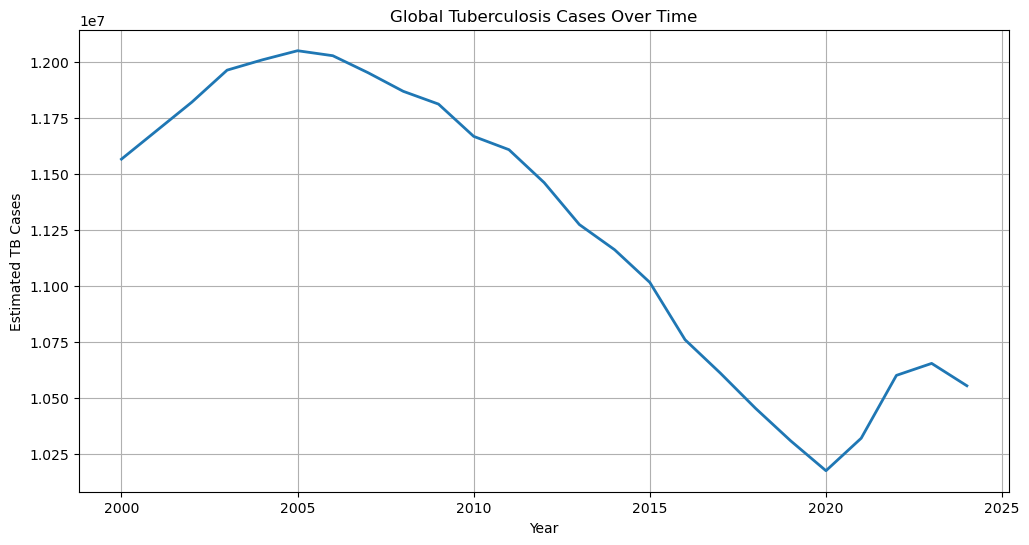

In [32]:
# Global TB Cases by Year

cases_by_year = tb.groupby("Year")["TB_Cases"].sum()

plt.figure(figsize=(12,6))
plt.plot(cases_by_year.index, cases_by_year.values, linewidth=2)

plt.title("Global Tuberculosis Cases Over Time")
plt.xlabel("Year")
plt.ylabel("Estimated TB Cases")

plt.grid(True)

plt.show()

In [ ]:
### 9.2 Global Tuberculosis Deaths Over Time

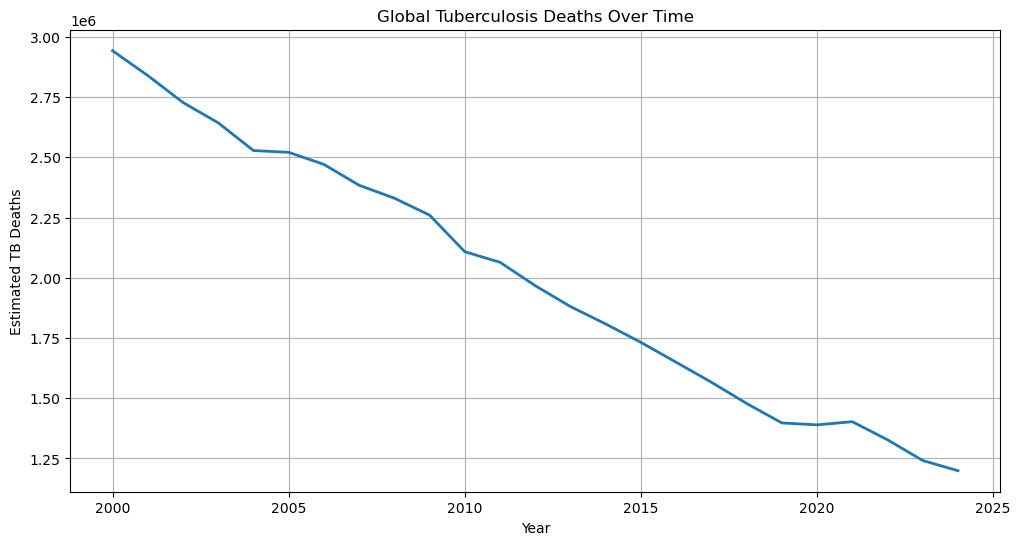

In [33]:
deaths_by_year = tb.groupby("Year")["TB_Deaths"].sum()

plt.figure(figsize=(12,6))
plt.plot(deaths_by_year.index, deaths_by_year.values, linewidth=2)

plt.title("Global Tuberculosis Deaths Over Time")
plt.xlabel("Year")
plt.ylabel("Estimated TB Deaths")

plt.grid(True)

plt.show()

In [ ]:
### 9.3 Average TB Incidence Rate

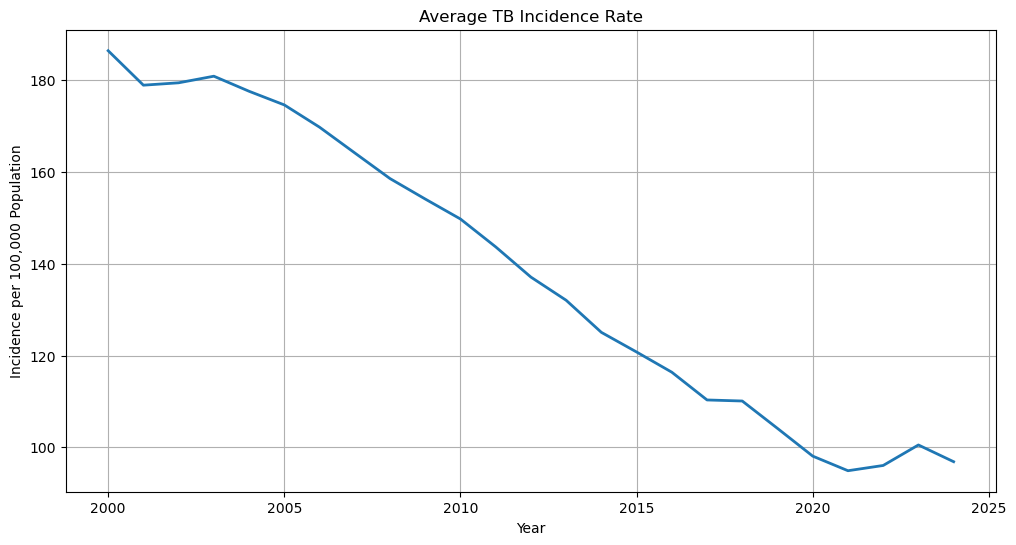

In [34]:
incidence = tb.groupby("Year")["TB_Incidence_Rate"].mean()

plt.figure(figsize=(12,6))
plt.plot(incidence.index, incidence.values, linewidth=2)

plt.title("Average TB Incidence Rate")
plt.xlabel("Year")
plt.ylabel("Incidence per 100,000 Population")

plt.grid(True)

plt.show()

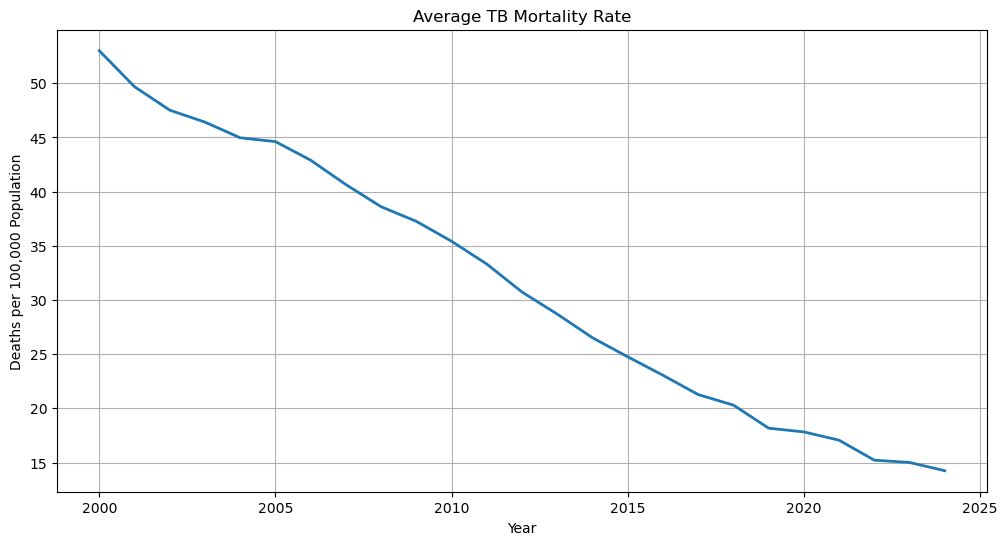

In [35]:
mortality = tb.groupby("Year")["TB_Mortality_Rate"].mean()

plt.figure(figsize=(12,6))
plt.plot(mortality.index, mortality.values, linewidth=2)

plt.title("Average TB Mortality Rate")
plt.xlabel("Year")
plt.ylabel("Deaths per 100,000 Population")

plt.grid(True)

plt.show()

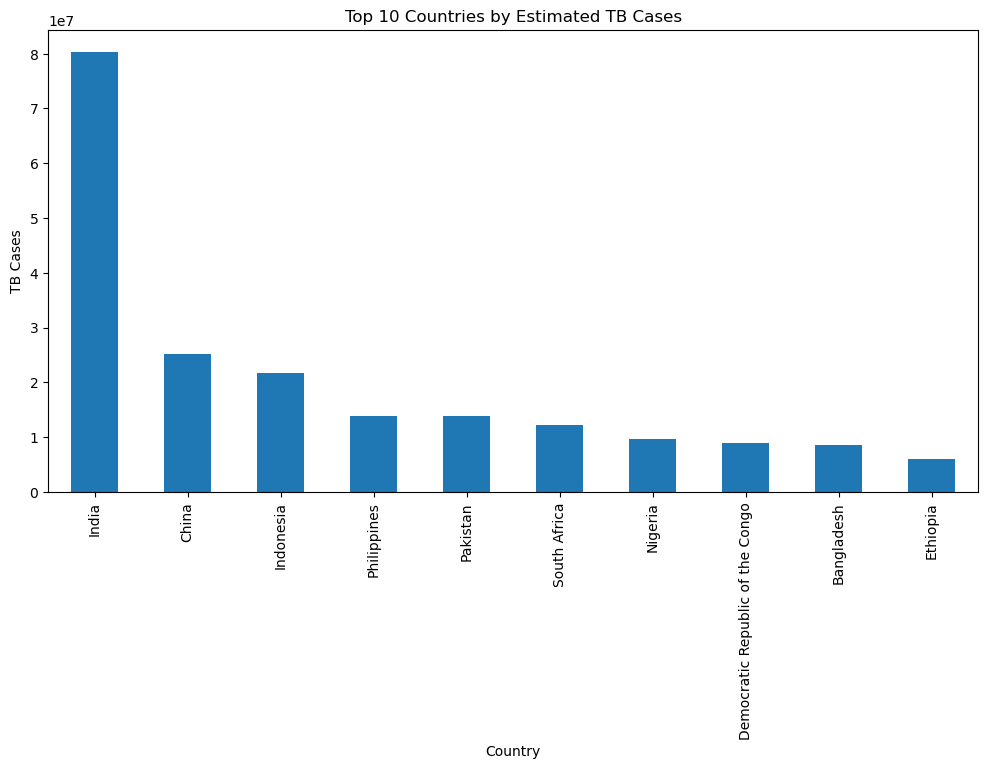

In [36]:
top10 = (
    tb.groupby("Country")["TB_Cases"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top10.plot(kind="bar")

plt.title("Top 10 Countries by Estimated TB Cases")
plt.ylabel("TB Cases")

plt.show()

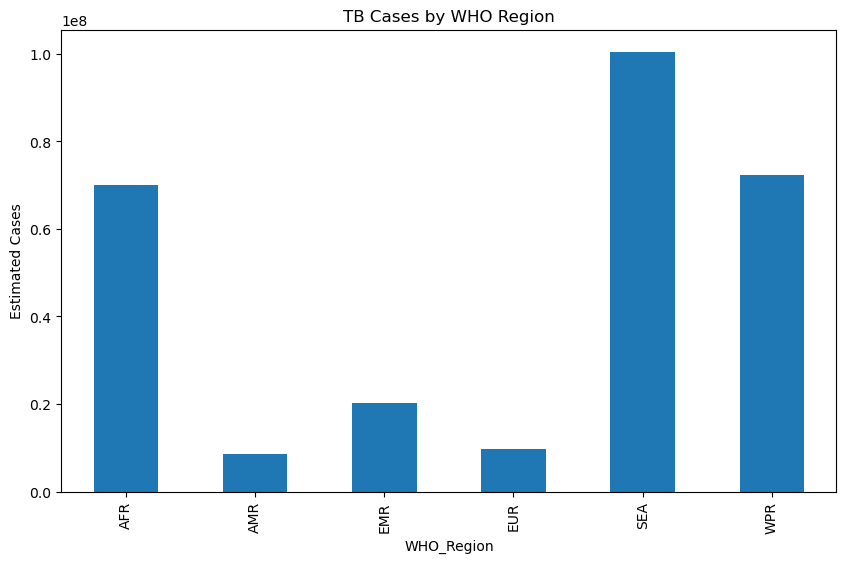

In [37]:
region = tb.groupby("WHO_Region")["TB_Cases"].sum()

plt.figure(figsize=(10,6))
region.plot(kind="bar")

plt.title("TB Cases by WHO Region")
plt.ylabel("Estimated Cases")

plt.show()

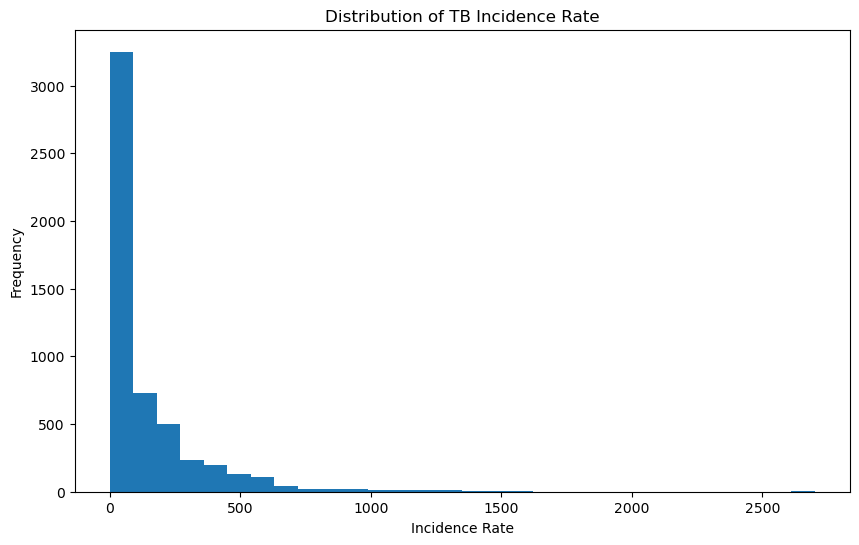

In [38]:
plt.figure(figsize=(10,6))

plt.hist(tb["TB_Incidence_Rate"], bins=30)

plt.title("Distribution of TB Incidence Rate")

plt.xlabel("Incidence Rate")

plt.ylabel("Frequency")

plt.show()

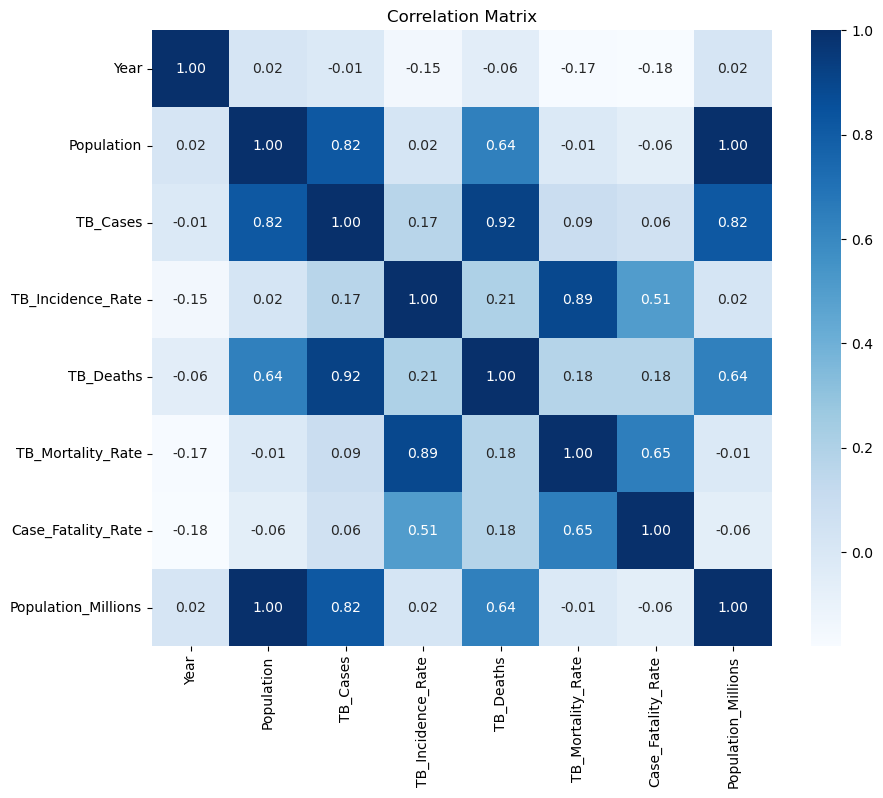

In [39]:
correlation = tb.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
## 10. Epidemiological Insights

This section summarizes key epidemiological findings derived from the tuberculosis dataset. These insights highlight disease burden, temporal trends, regional differences, and high-risk countries, providing evidence to support public health planning and decision-making.

In [40]:
print(f"Total Countries: {tb['Country'].nunique()}")

Total Countries: 217


In [41]:
print(f"Study Period: {tb['Year'].min()} - {tb['Year'].max()}")

Study Period: 2000 - 2024


In [42]:
total_cases = tb["TB_Cases"].sum()

print(f"Total Estimated TB Cases: {total_cases:,.0f}")

Total Estimated TB Cases: 281,399,806


In [43]:
total_deaths = tb["TB_Deaths"].sum()

print(f"Total Estimated TB Deaths: {total_deaths:,.0f}")

Total Estimated TB Deaths: 49,858,717


In [44]:
avg_incidence = tb["TB_Incidence_Rate"].mean()

print(f"Average TB Incidence Rate: {avg_incidence:.2f} per 100,000 population")

Average TB Incidence Rate: 138.21 per 100,000 population


In [45]:
avg_mortality = tb["TB_Mortality_Rate"].mean()

print(f"Average TB Mortality Rate: {avg_mortality:.2f} per 100,000 population")

Average TB Mortality Rate: 31.41 per 100,000 population


In [46]:
avg_cfr = tb["Case_Fatality_Rate"].mean()

print(f"Average Case Fatality Rate: {avg_cfr:.2f}%")

Average Case Fatality Rate: 16.32%


In [47]:
highest_cases = (
    tb.groupby("Country")["TB_Cases"]
      .sum()
      .idxmax()
)

highest_cases_value = (
    tb.groupby("Country")["TB_Cases"]
      .sum()
      .max()
)

print(f"Highest TB Burden: {highest_cases} ({highest_cases_value:,.0f} cases)")

Highest TB Burden: India (80,320,000 cases)


In [48]:
highest_deaths = (
    tb.groupby("Country")["TB_Deaths"]
      .sum()
      .idxmax()
)

highest_deaths_value = (
    tb.groupby("Country")["TB_Deaths"]
      .sum()
      .max()
)

print(f"Highest TB Deaths: {highest_deaths} ({highest_deaths_value:,.0f} deaths)")

Highest TB Deaths: India (14,151,000 deaths)


In [49]:
highest_region = (
    tb.groupby("WHO_Region")["TB_Cases"]
      .sum()
      .idxmax()
)

highest_region_value = (
    tb.groupby("WHO_Region")["TB_Cases"]
      .sum()
      .max()
)

print(f"Highest Burden WHO Region: {highest_region} ({highest_region_value:,.0f} cases)")

Highest Burden WHO Region: SEA (100,480,800 cases)


In [50]:
year_cases = tb.groupby("Year")["TB_Cases"].sum()

peak_year = year_cases.idxmax()

peak_cases = year_cases.max()

print(f"Peak Year: {peak_year} ({peak_cases:,.0f} cases)")

Peak Year: 2005 (12,051,805 cases)


In [51]:
summary = pd.DataFrame({
    "Indicator": [
        "Countries",
        "Study Period",
        "Total TB Cases",
        "Total TB Deaths",
        "Average Incidence Rate",
        "Average Mortality Rate",
        "Average CFR (%)"
    ],
    "Value": [
        tb["Country"].nunique(),
        f"{tb['Year'].min()} - {tb['Year'].max()}",
        f"{tb['TB_Cases'].sum():,.0f}",
        f"{tb['TB_Deaths'].sum():,.0f}",
        f"{tb['TB_Incidence_Rate'].mean():.2f}",
        f"{tb['TB_Mortality_Rate'].mean():.2f}",
        f"{tb['Case_Fatality_Rate'].mean():.2f}%"
    ]
})

summary

,Indicator,Value
0,Countries,217
1,Study Period,2000 - 2024
2,Total TB Cases,"281,399,806"
3,Total TB Deaths,"49,858,717"
4,Average Incidence Rate,138.21
5,Average Mortality Rate,31.41
6,Average CFR (%),16.32%


In [ ]:
## 11. Key Findings

The exploratory analysis of the WHO Global Tuberculosis dataset revealed several important epidemiological findings:

- The dataset covers tuberculosis estimates across multiple countries and WHO regions over several years, providing a comprehensive overview of the global TB burden.

- Tuberculosis remains a major public health challenge, with millions of estimated cases and deaths reported throughout the study period.

- The global trend analysis showed temporal changes in TB incidence and mortality, reflecting progress in TB control in some regions while highlighting persistent challenges in others.

- A small number of countries account for a substantial proportion of the global TB burden, indicating the need for targeted interventions.

- Significant differences were observed across WHO regions, demonstrating geographical inequalities in tuberculosis burden.

- The analysis identified countries with the highest estimated TB cases and TB-related deaths, emphasizing priority areas for disease control.

- Case Fatality Rate (CFR) varied across countries and years, suggesting differences in healthcare access, diagnostic capacity, and treatment outcomes.

- The interactive dashboard enables efficient monitoring of tuberculosis indicators and supports evidence-based public health decision-making.

In [ ]:
# 12. Recommendations

Based on the epidemiological findings and data analysis, the following recommendations are proposed:

### 1. Strengthen Early Detection and Diagnosis
- Improve access to TB screening services, especially in high-burden countries.
- Expand active case-finding strategies among vulnerable populations.
- Promote rapid diagnostic tools to reduce delays in treatment initiation.

### 2. Improve Treatment Coverage and Patient Management
- Increase treatment coverage in countries with high TB incidence rates.
- Strengthen adherence support programs to reduce treatment interruption.
- Improve monitoring of treatment outcomes through reliable surveillance systems.

### 3. Prioritize High-Mortality Regions
- Allocate additional healthcare resources to regions with elevated TB mortality rates.
- Focus interventions on populations at higher risk of severe outcomes.
- Integrate TB control programs with HIV and primary healthcare services.

### 4. Enhance Data-Driven Decision Making
- Develop interactive dashboards to monitor key TB indicators, including:
  - TB incidence rate
  - TB mortality rate
  - Case fatality rate (CFR)
  - Treatment coverage
- Use data visualization tools such as Power BI to support public health planning and resource allocation.

### 5. Maintain Regular Data Updates
- Update epidemiological datasets periodically using the latest releases from the World Health Organization (WHO).
- Improve data quality through standardized reporting and validation processes.
- Encourage continuous surveillance to detect emerging trends and changes in TB patterns.

### Conclusion
The analysis highlights significant variations in TB burden across countries and regions. Implementing targeted interventions, strengthening surveillance systems, and leveraging data analytics can contribute to reducing TB transmission and mortality worldwide.

In [ ]:
# 13. Export Clean Dataset

The cleaned and processed dataset will be exported as a CSV file to enable further analysis and visualization using business intelligence tools such as Power BI.

The exported dataset can be used for:
- Creating interactive TB surveillance dashboards.
- Monitoring epidemiological indicators.
- Supporting evidence-based public health decisions.

In [54]:
# Export cleaned dataset to CSV

tb.to_csv("TB_Clean_Dataset.csv", index=False)

print("Clean dataset exported successfully!")

Clean dataset exported successfully!
